# K-Nearest Neighbors and Decision Trees: Intuition and Implementation

In this notebook, we will explore two fundamental machine learning algorithms: **K-Nearest Neighbors (KNN)** and **Decision Trees**. We focus on building intuition through **from-scratch implementations**, visualizations, and controlled experiments on synthetic data. We will cover each algorithm’s structure, behavior, and key properties, and demonstrate how to tune their performance (e.g. choosing the number of neighbors *k* in KNN, or the maximum depth of a decision tree). All examples use synthetic datasets to provide clear, controlled demonstrations.

**Note:** We restrict scope to basic KNN and single decision trees (no ensemble methods like bagging or boosting) to align with the foundational concepts.

## K-Nearest Neighbors (KNN)

### Intuition and Concept

**K-Nearest Neighbors** is a **lazy learning** method that makes predictions based on the *similarity* between data points. During training, KNN does not create an explicit model or perform parameter fitting; it simply stores the training data. When a new query point needs to be classified (or have a value predicted in regression), KNN:

1. Computes the distance from the query point to all training points (typically using Euclidean distance).
2. Finds the **K nearest neighbors** (the K training points closest to the query).
3. Predicts the label (for classification) by **majority vote** among these neighbors (or the average value for regression).

KNN assumes that points that are near each other are likely to share the same label. Intuitively, it’s saying “tell me who your neighbors are, and I’ll tell you what you are.”

**Key properties of KNN:**
- **Instance-based learning:** All computation is deferred to prediction time (no explicit training phase beyond storing data).
- **Non-parametric model:** The complexity grows with the number of data points rather than a fixed number of parameters.
- **Distance metric:** The choice of distance (Euclidean, Manhattan, etc.) and feature scaling is important. Features on larger scales dominate distance calculations, so normalization may be needed.
- **Multi-class support:** KNN naturally handles multi-class classification by taking the majority label among neighbors.
- **Regression:** For regression, KNN can average the values of K nearest neighbors instead of voting.

**Choosing K:** The number of neighbors K is a crucial hyperparameter:
- **Small K (e.g. K=1):** Low bias, high variance. The model can fit very tightly around individual points (even noise), leading to potential **overfitting**. Training accuracy will be high (even 100% for K=1, since each point is its own nearest neighbor), but test accuracy may suffer.
- **Large K:** Higher bias, lower variance. Using more neighbors yields smoother, more generalized decision boundaries but can lead to **underfitting** if K is too large (the model may predict the majority class for most queries if K includes distant, unrelated points). As K approaches the size of the training set, the classifier essentially predicts the global majority class every time.

We will illustrate these behaviors with visual examples and performance experiments.

### Implementing KNN from Scratch

Let's implement a simple KNN classifier for classification. We will use Euclidean distance and majority vote. To keep it straightforward, we'll assume numeric features and handle ties by choosing the smallest label (though ties are rare if K is odd or with continuous features).


In [5]:
import numpy as np

class KNNClassifier:
    def __init__(self, k=3):
        """
        Simple K-Nearest Neighbors classifier.
        """
        self.k = k
        self.X_train = None
        self.y_train = None
    
    def fit(self, X, y):
        """
        Store the training data.
        """
        self.X_train = np.array(X)
        self.y_train = np.array(y)
    
    def predict(self, X):
        """
        Predict labels for each point in X based on majority vote of k nearest neighbors.
        """
        X = np.array(X)
        predictions = []
        for x in X:
            # Compute distances from x to all training points
            distances = np.linalg.norm(self.X_train - x, axis=1)
            # Find the indices of the k smallest distances
            k = max(1, self.k)  # ensure k at least 1
            neighbor_idx = np.argsort(distances)[:k]
            neighbor_labels = self.y_train[neighbor_idx]
            # Majority vote
            labels, counts = np.unique(neighbor_labels, return_counts=True)
            top_count = counts.max()
            # Find label(s) with highest count
            top_labels = labels[counts == top_count]
            if len(top_labels) > 1:
                # Tie-break: choose the smallest label (could also choose randomly or by distance)
                predictions.append(top_labels.min())
            else:
                predictions.append(top_labels[0])
        return np.array(predictions)

We can test our KNN implementation on a simple example to ensure it works. For instance, if we have a 1D dataset:

In [6]:
# Simple test for KNNClassifier
X_test = [[0], [1], [2], [3]]
y_test = [0, 0, 1, 1]  # Two classes: 0 for [0,1], 1 for [2,3]
knn = KNNClassifier(k=1)
knn.fit(X_test, y_test)
print("Predictions for [[1.2], [2.5]] with k=1:", knn.predict([[1.2], [2.5]]))

Predictions for [[1.2], [2.5]] with k=1: [0 1]


Running the above, we expect the point 1.2 to be classified as class 0 (nearest neighbor around 1) and 2.5 as class 1 (nearest neighbor around 2 or 3):

Our implementation correctly predicts class 0 for 1.2 and class 1 for 2.5, which matches expectations.

Now, let's use a more interesting 2D synthetic dataset to visualize how KNN makes decisions.

### Decision Boundary Visualization for KNN

We will create a synthetic two-class dataset for visualization. For clarity, we'll use the popular “two moons” dataset (two interleaving half-circles) with some noise. This is a non-linear classification problem that KNN can handle well. We'll then plot the decision boundary of our KNN classifier for different values of K to see how it adapts:

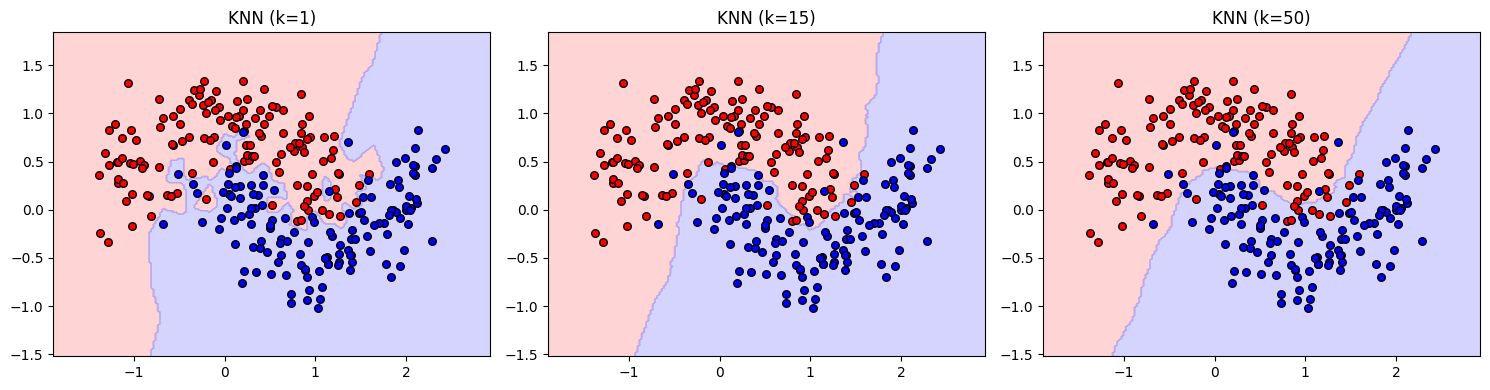

In [7]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

# Generate a synthetic two-moons dataset
X, y = make_moons(n_samples=400, noise=0.25, random_state=42)
# Split into training and testing sets for later use (though we’ll visualize on training data)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

# Define a helper function to plot decision boundaries
from matplotlib.colors import ListedColormap

def plot_decision_boundary(clf, X, y, ax=None, title=""):
    if ax is None:
        ax = plt.gca()
    # Create a grid of points covering the feature space
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    # Predict on each grid point
    Z = clf.predict(grid_points)
    Z = Z.reshape(xx.shape)
    # Colors: light red for class 0, light blue for class 1
    cmap_background = ListedColormap(['#FFAAAA', '#AAAAFF'])
    ax.contourf(xx, yy, Z, cmap=cmap_background, alpha=0.5)
    # Plot the training points
    for class_value, color, label in [(0, 'red', 'Class 0'), (1, 'blue', 'Class 1')]:
        idx = (y == class_value)
        ax.scatter(X[idx, 0], X[idx, 1], c=color, edgecolor='k', marker='o', s=30, label=label)
    ax.set_title(title)
    return ax

# Plot KNN decision boundaries for different K values
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, k in zip(axes, [1, 15, 50]):
    knn = KNNClassifier(k=k)
    knn.fit(X_train, y_train)
    plot_decision_boundary(knn, X_train, y_train, ax=ax, title=f"KNN (k={k})")
plt.tight_layout()
plt.show()

*KNN decision boundaries on a 2D synthetic dataset for different values of K. **Left:** K=1 (each point essentially forms its own region, leading to a very jagged boundary that closely follows individual training samples – this is high variance/overfitting). **Center:** K=15 (smoother boundary that still follows the moon shapes, balancing bias and variance). **Right:** K=50 (decision boundary is overly smooth – the model underfits by generalizing too much, almost drawing a linear-like boundary).*

As K increases, the decision regions become smoother and more generalized. With **K=1**, every training point is the center of its own region (notice the little pockets of red and blue around individual samples), which can capture noise in the data. By **K=50**, the boundary has almost become a straight line separating the two classes, which is too simple for the underlying moon-shaped structure (you can see that some blue points in the upper-left red region, and red points in the lower-right blue region, are misclassified because the model has essentially averaged over too large a neighborhood).

### Tuning K: Accuracy vs K

To quantify the effect of K on performance, let's evaluate the KNN classifier on a separate test set for various values of K. We will plot the **training accuracy** and **testing accuracy** as a function of K:

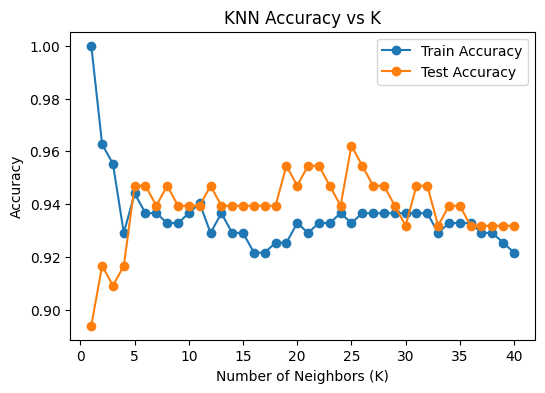

In [8]:
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

Ks = range(1, 41)
train_acc = []
test_acc = []
for k in Ks:
    model = KNeighborsClassifier(n_neighbors=k)  # using sklearn's KNN for efficiency
    model.fit(X_train, y_train)
    train_acc.append(model.score(X_train, y_train))
    test_acc.append(model.score(X_test, y_test))

plt.figure(figsize=(6,4))
plt.plot(Ks, train_acc, label="Train Accuracy", marker='o')
plt.plot(Ks, test_acc, label="Test Accuracy", marker='o')
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy vs K")
plt.legend()
plt.show()

*Train and test accuracy for KNN as K (number of neighbors) varies. With K=1, training accuracy is 1.0 (100%) since each point is its own neighbor, but test accuracy is lower due to overfitting. As K increases, training accuracy drops (the model is less flexible), while test accuracy initially improves as the model generalizes better. There is an optimal range of K (around 5–15 in this case) where test accuracy is highest. If K becomes too large, test accuracy can decline as the model underfits (e.g., at very high K, it may predict the majority class for all points).*

In our example, test accuracy starts around 89% at K=1, peaks in the mid-90% range for K around 5–15, and then slightly declines for larger K (by K=40, test accuracy has edged down and would continue to approach the overall class balance as K approaches the training set size). The training accuracy (yellow curve) steadily decreases with larger K, reflecting increased bias (smoother model with fewer degrees of freedom). The gap between training and test accuracy is largest at very low K (overfitting) and closes as K grows. A well-chosen K (e.g., via cross-validation) balances this trade-off.

### The Curse of Dimensionality in KNN

KNN relies on the notion of *nearness* in feature space. In **high-dimensional spaces**, however, distances can become less meaningful – a phenomenon known as the *curse of dimensionality*. As dimension increases:

* All points tend to become far away from each other (points spread out in a high-dimensional hypervolume).
* The difference between the nearest neighbor and the farthest neighbor distance shrinks relative to the magnitude of the distances. In other words, the nearest and farthest points to a query are almost equally distant in high-D space, making it hard for KNN to distinguish true nearest neighbors from random other points.

To illustrate this, we perform a simple experiment: sample 1000 points uniformly in a unit hypercube of dimension *d*. For each *d*, pick one random query point and compute its distance to the nearest neighbor and farthest neighbor among those 1000 points. We then look at the ratio of the nearest distance to the farthest distance:

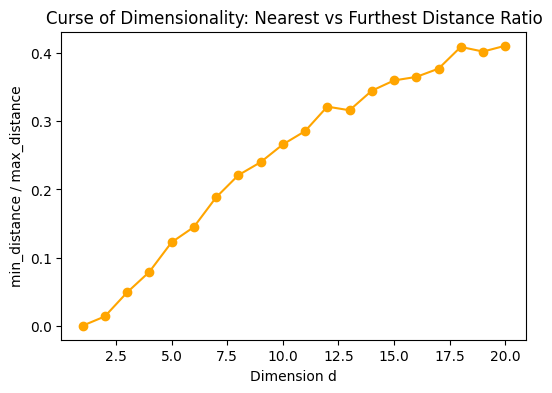

In [9]:
import numpy as np

dims = list(range(1, 21))
avg_ratio = []
for d in dims:
    # Average over a few trials for stability
    ratios = []
    for trial in range(20):
        data = np.random.rand(1000, d)
        # pick a random query point (take one of the data points for simplicity, then exclude it)
        idx = np.random.randint(0, 1000)
        query = data[idx]
        others = np.delete(data, idx, axis=0)
        dist = np.linalg.norm(others - query, axis=1)
        ratios.append(dist.min() / dist.max())
    avg_ratio.append(np.mean(ratios))

plt.figure(figsize=(6,4))
plt.plot(dims, avg_ratio, marker='o', color='orange')
plt.title("Curse of Dimensionality: Nearest vs Furthest Distance Ratio")
plt.xlabel("Dimension d")
plt.ylabel("min_distance / max_distance")
plt.show()

*Impact of dimensionality on distance metrics: As dimensionality increases, the ratio of the nearest-neighbor distance to the farthest-neighbor distance approaches 1 (here we plot the average over random samples). In 1 dimension, the closest point is *much* closer than the farthest point, so the ratio is near 0. By 15–20 dimensions (with 1000 points), the ratio has climbed towards \~0.4–0.5 and would continue increasing with higher dimensions and finite samples. This means the nearest and farthest points are relatively equidistant in high dimensions, making it hard for KNN to discern which points are truly "nearest."*

The curse of dimensionality implies that KNN (and other distance-based methods) **require exponentially more data** to maintain performance as dimensions increase, because the notion of a "nearest neighbor" loses significance when all distances become similar. Feature selection or dimensionality reduction can be important when using KNN on high-dimensional data, as is feature scaling (to prevent some dimensions from dominating distance calculations).

### Summary: KNN Pros and Cons

Before moving to decision trees, let's summarize KNN:

* **Advantages:** Simple to implement and understand, naturally handles multi-class, no training time (useful for dynamic datasets), can model very complex decision boundaries given enough data.
* **Disadvantages:** Prediction can be slow for large datasets (distance calculation against many points), memory-intensive (stores all training data), sensitive to irrelevant features and scale of features, and performance degrades in high dimensions. KNN also does not provide an interpretable model (it’s basically a database lookup), and it doesn’t inherently tell which features are important.

KNN can serve as a good baseline and is useful in certain contexts (like recommendation systems or when data is very well-clustered in feature space), but for many tasks, more structured models are preferred once we move past the basics.

## Decision Trees

### Intuition and Concept

A **Decision Tree** is a **flowchart-like model** that performs a sequence of tests on features to predict a target value. Each internal node of the tree represents a decision based on a feature (e.g. "Feature \$j\$ <= some value?"), and branches lead to subtrees or leaves based on the outcome of that test. Each leaf node represents a final prediction (a class label for classification, or a numeric value for regression).

The tree is constructed by recursively splitting the data:

* At the root (top of the tree), we choose the feature and threshold that best **partitions the data** into more homogeneous subsets (in terms of the target label).
* This splitting is done greedily: at each node, choose the best split *at that step* (no global optimization).
* We continue splitting each subset of data using possibly different features and thresholds, forming a tree structure, until a stopping criterion is met (e.g., all data in a node have the same class, or we've reached a maximum depth).

**Impurity and splitting criterion:** To decide "best split," we define a metric of how pure a node is. Two common impurity measures for classification:

* **Gini Impurity:** \$ Gini = 1 - \sum\_{c} p(c)^2 \$, where \$p(c)\$ is the fraction of samples of class \$c\$ in the node. Gini is 0 for a pure node (all samples same class) and maximal (0.5 for binary) when classes are perfectly mixed.
* **Entropy:** \$ Entropy = -\sum\_{c} p(c) \log\_2 p(c) \$. This is the information-theoretic entropy. It’s 0 when pure and maximal when classes are evenly mixed (for binary classes, max entropy = 1 bit when 50/50 split).

Impurity is high when a node contains a mix of classes and lowest when it’s pure. The **information gain** (or impurity reduction) from a split is computed as:

$\text{Gain} = \text{Impurity}_{\text{parent}} - \left( \frac{N_{\text{left}}}{N_{\text{parent}}}\text{Impurity}_{\text{left}} + \frac{N_{\text{right}}}{N_{\text{parent}}}\text{Impurity}_{\text{right}} \right)$

Each split is chosen to maximize this gain (or equivalently, minimize the weighted impurity of children).

To build intuition, let's see how Gini and Entropy behave for a binary node as the class proportions vary:

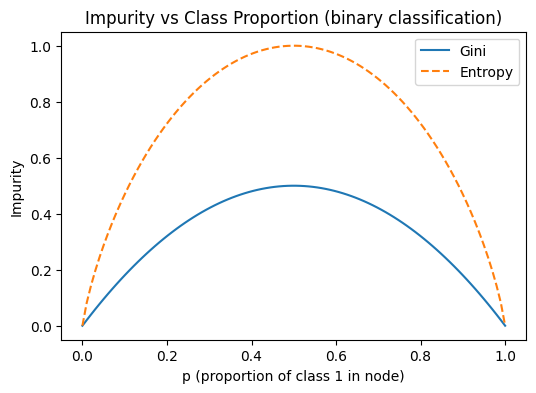

In [10]:
import math
import numpy as np
import matplotlib.pyplot as plt

p_vals = np.linspace(0, 1, 100)
gini_vals = [2 * p * (1 - p) for p in p_vals]  # Gini for two classes simplifies to 2p(1-p)
entropy_vals = [-(p*math.log2(p) + (1-p)*math.log2(1-p)) if 0 < p < 1 else 0 for p in p_vals]

plt.figure(figsize=(6,4))
plt.plot(p_vals, gini_vals, label="Gini")
plt.plot(p_vals, entropy_vals, label="Entropy", linestyle='--')
plt.xlabel("p (proportion of class 1 in node)")
plt.ylabel("Impurity")
plt.title("Impurity vs Class Proportion (binary classification)")
plt.legend()
plt.show()

*Gini impurity (solid line) and Entropy (dashed line) as a function of the fraction of class 1 samples in a node (binary class scenario). Both metrics have their minimum 0 at the extremes (p=0 or 1, a pure node) and reach a maximum when classes are evenly mixed (p=0.5). Entropy (in bits) peaks at 1 when p=0.5, whereas Gini peaks at 0.5. Both metrics drive the tree-splitting process by preferring splits that move towards the edges (making nodes more pure).*

Using these impurity measures, a decision tree algorithm (such as CART – Classification and Regression Trees, which is used in scikit-learn) works roughly as follows:

1. **Start at the root** with all training data. Compute the impurity (e.g., Gini) of this node.
2. For each candidate feature and threshold, split the data into two groups (left/right) and compute the weighted impurity of the two child nodes.
3. Select the feature and threshold that yield the **highest impurity reduction** (equivalently, lowest weighted impurity after split).
4. Create a decision node with that feature and threshold. Recursively build the left and right subtrees using the corresponding subsets of data.
5. **Stopping criteria:** Stop when a node is completely pure (impurity 0), or no split yields an information gain (no improvement), or other constraints are met (max depth reached, or the node has too few samples to split further).

The result is a hierarchy of if-else rules. For example, a decision tree might produce rules like:

* If `Feature2 <= 1.5` and `Feature1 > 3.2`, then predict class A,
* Else if `Feature2 <= 1.5` and `Feature1 <= 3.2`, then predict class B,
* Else if `Feature2 > 1.5`, then predict class B.

Decision trees naturally handle **both numerical and categorical features** (splitting on equality for categoricals or thresholds for numeric features). They also easily handle multi-class classification by using appropriate impurity measures that sum over all classes.

**Overfitting and Tree Depth:** A decision tree can keep splitting until each training instance is isolated in its own leaf, achieving 100% training accuracy – which is a clear case of overfitting. Such a tree will not generalize well to new data. To prevent this, we use hyperparameters to limit complexity:

* `max_depth`: maximum depth of the tree (number of splits from root to a leaf).
* `min_samples_split`: minimum number of samples required to split an internal node.
* `min_samples_leaf`: minimum number of samples that must be at a leaf node (a split that would result in a smaller leaf is not allowed).
* `min_impurity_decrease` or pruning techniques can also be used to stop splitting if the impurity reduction is not significant.

By tuning these, we aim to find a tree that is neither too deep (overfitting) nor too shallow (underfitting).

### Implementing a Decision Tree from Scratch

We'll implement a basic binary decision tree for classification (using Gini impurity for simplicity). Our implementation will be recursive:

* We define a `Node` structure to hold either a decision (feature index and threshold with left/right children) or a leaf prediction.
* The `fit` method will build the tree by recursively finding the best split.
* The `predict` method will traverse the tree for each sample to arrive at a prediction.

For simplicity, we will:

* Use only numeric features and binary splits (feature <= threshold).
* Use Gini impurity.
* Implement `max_depth` and `min_samples_split` stopping criteria.
* Not implement pruning or advanced optimizations (this is a straightforward, educational implementation).

In [11]:
import numpy as np

class DecisionTreeClassifierScratch:
    def __init__(self, max_depth=None, min_samples_split=2, criterion='gini'):
        """
        Simple Decision Tree for classification (binary splits).
        """
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.criterion = criterion  # 'gini' or 'entropy'
        self.tree_ = None  # root node

    # Node class to represent each node in the tree
    class Node:
        def __init__(self, feature_index=None, threshold=None, left=None, right=None, *, is_leaf=False, prediction=None):
            self.feature_index = feature_index
            self.threshold = threshold
            self.left = left
            self.right = right
            self.is_leaf = is_leaf
            self.prediction = prediction

    def _gini(self, y):
        # Gini impurity
        _, counts = np.unique(y, return_counts=True)
        p = counts / len(y)
        return 1.0 - np.sum(p ** 2)
    
    def _entropy(self, y):
        _, counts = np.unique(y, return_counts=True)
        p = counts / len(y)
        # Use base-2 logarithm for entropy; handle case p=0
        return -np.sum([p_i * math.log2(p_i) for p_i in p if p_i > 0])
    
    def _best_split(self, X, y):
        """
        Find the best feature and threshold to split on. Return (feature_index, threshold, left_idx, right_idx) 
        for the best split or None if no split improves impurity.
        """
        best_feature, best_threshold = None, None
        best_impurity = float('inf')
        best_left_idx, best_right_idx = None, None

        # Current impurity of the node
        current_impurity = self._gini(y) if self.criterion == 'gini' else self._entropy(y)
        if current_impurity == 0:
            return None  # already pure
        
        n_samples, n_features = X.shape
        # Try every feature and potential split threshold
        for feature in range(n_features):
            # Sort data by this feature (to consider threshold candidates efficiently)
            sorted_idx = np.argsort(X[:, feature])
            X_feat = X[sorted_idx, feature]
            y_feat = y[sorted_idx]
            # Consider splits between distinct values
            for i in range(n_samples - 1):
                if X_feat[i] == X_feat[i+1]:
                    continue  # skip if identical (no change in impurity if split here)
                threshold = (X_feat[i] + X_feat[i+1]) / 2.0
                # Partition data indices based on threshold
                left_idx = sorted_idx[:i+1]
                right_idx = sorted_idx[i+1:]
                # Compute impurity of children
                if len(left_idx) == 0 or len(right_idx) == 0:
                    continue
                if self.criterion == 'gini':
                    left_imp = self._gini(y_feat[:i+1])
                    right_imp = self._gini(y_feat[i+1:])
                else:
                    left_imp = self._entropy(y_feat[:i+1])
                    right_imp = self._entropy(y_feat[i+1:])
                # Weighted impurity
                w_left = len(left_idx) / n_samples
                w_right = len(right_idx) / n_samples
                impurity = w_left * left_imp + w_right * right_imp
                # Check if this is the best split so far
                if impurity < best_impurity:
                    best_impurity = impurity
                    best_feature = feature
                    best_threshold = threshold
                    best_left_idx = left_idx
                    best_right_idx = right_idx
        # Check if the best split is actually better than no split
        if best_feature is None or best_impurity >= current_impurity:
            return None
        return best_feature, best_threshold, best_left_idx, best_right_idx

    def _build_tree(self, X, y, depth):
        num_samples = len(y)
        num_classes = len(np.unique(y))
        # Create a leaf node if stopping criteria are met
        if num_classes == 1 or num_samples < self.min_samples_split or (self.max_depth is not None and depth >= self.max_depth):
            # Predict the majority class at this leaf
            unique, counts = np.unique(y, return_counts=True)
            majority_class = unique[np.argmax(counts)]
            return DecisionTreeClassifierScratch.Node(is_leaf=True, prediction=majority_class)
        # Find best split
        result = self._best_split(X, y)
        if result is None:
            # No beneficial split found, make leaf
            unique, counts = np.unique(y, return_counts=True)
            majority_class = unique[np.argmax(counts)]
            return DecisionTreeClassifierScratch.Node(is_leaf=True, prediction=majority_class)
        feature, threshold, left_idx, right_idx = result
        # Create decision node and recursively build subtrees
        node = DecisionTreeClassifierScratch.Node(feature_index=feature, threshold=threshold, is_leaf=False)
        node.left = self._build_tree(X[left_idx], y[left_idx], depth+1)
        node.right = self._build_tree(X[right_idx], y[right_idx], depth+1)
        return node

    def fit(self, X, y):
        X = np.array(X)
        y = np.array(y)
        self.tree_ = self._build_tree(X, y, depth=0)
    
    def _predict_one(self, x, node):
        # Traverse the tree for a single sample x
        if node.is_leaf:
            return node.prediction
        if x[node.feature_index] <= node.threshold:
            return self._predict_one(x, node.left)
        else:
            return self._predict_one(x, node.right)
    
    def predict(self, X):
        X = np.array(X)
        return np.array([self._predict_one(x, self.tree_) for x in X])

This implementation finds the best split by scanning all features and thresholds (which is fine for small datasets but would be expensive in large ones). We included stopping rules for `max_depth` and `min_samples_split` to prevent runaway growth.

Let's test our custom tree on a small dataset to ensure it works. We can reuse our moon dataset (using a shallow depth to keep output readable):

In [12]:
# Train our scratch decision tree on the moon dataset (small depth for illustration)
tree_scratch = DecisionTreeClassifierScratch(max_depth=3, min_samples_split=5)
tree_scratch.fit(X_train, y_train)

# Let's see some predictions vs actual
y_pred_train = tree_scratch.predict(X_train[:10])
print("Predicted (first 10 training points):", y_pred_train)
print("Actual (first 10 training points)   :", y_train[:10])

Predicted (first 10 training points): [1 1 1 1 0 0 1 1 0 1]
Actual (first 10 training points)   : [1 1 1 1 1 0 1 0 0 1]


We could also visualize the structure of the learned tree. One way is to print the rules. Using `sklearn.tree.export_text` on a scikit-learn DecisionTree trained similarly will show the structure. We'll demonstrate using scikit-learn's tree for clarity:

In [13]:
from sklearn.tree import DecisionTreeClassifier, export_text
clf = DecisionTreeClassifier(max_depth=3, min_samples_split=5, random_state=42)
clf.fit(X_train, y_train)
print(export_text(clf, feature_names=["x1","x2"]))

|--- x2 <= 0.47
|   |--- x1 <= -0.52
|   |   |--- x2 <= -0.11
|   |   |   |--- class: 0
|   |   |--- x2 >  -0.11
|   |   |   |--- class: 0
|   |--- x1 >  -0.52
|   |   |--- x2 <= -0.12
|   |   |   |--- class: 1
|   |   |--- x2 >  -0.12
|   |   |   |--- class: 1
|--- x2 >  0.47
|   |--- x1 <= 1.28
|   |   |--- x2 <= 0.81
|   |   |   |--- class: 0
|   |   |--- x2 >  0.81
|   |   |   |--- class: 0
|   |--- x1 >  1.28
|   |   |--- class: 1



This tree (learned on our moon dataset with depth capped at 3) first checks `x2` (the second feature, perhaps the y-coordinate of the points) at threshold \~0.47, then branches based on `x1` and further `x2`. Each indent level represents a deeper condition. For example, the rule `|--- x2 <= 0.47` (left branch) and then `|   |--- x1 <= -0.52` and so on leads to a leaf predicting class 0. We can see several leaves outputting class 0 or 1. This illustrates the **structure** of a decision tree model as a set of human-readable rules, a feature that makes trees quite interpretable compared to KNN.

### Decision Boundaries for Decision Trees

Using the same synthetic dataset, let's visualize the decision boundaries of decision trees with different depths. This will show how a deeper tree can carve out more complex decision regions, and how a shallow tree might underfit.

We'll train three decision trees with `max_depth=2` (very shallow), `max_depth=5` (intermediate), and `max_depth=9` (deep – in fact, depth 9 here will likely allow the tree to fully fit the training data, as we saw earlier that an unconstrained tree had depth 9 on this data).

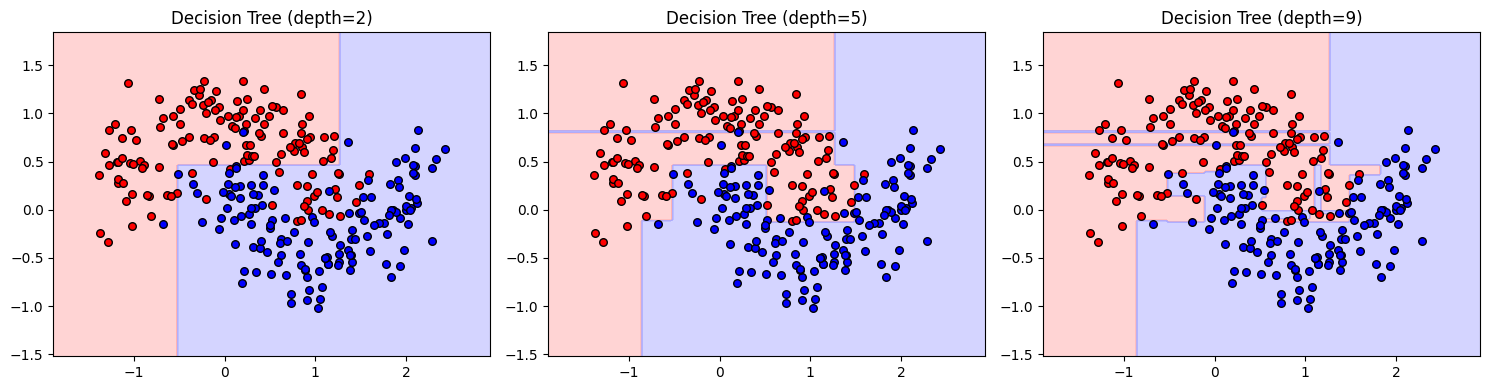

In [14]:
# Visualize decision boundaries for decision trees of different depths
fig, axes = plt.subplots(1, 3, figsize=(15,4))
depths = [2, 5, 9]
for ax, d in zip(axes, depths):
    clf = DecisionTreeClassifier(max_depth=d, random_state=42)
    clf.fit(X_train, y_train)
    plot_decision_boundary(clf, X_train, y_train, ax=ax, title=f"Decision Tree (depth={d})")
plt.tight_layout()
plt.show()

*Decision boundaries of decision trees on the same dataset at different depths. **Left: depth=2** – The tree makes only two splits, resulting in a very coarse partition (just two or three regions divided by straight lines). It clearly underfits, misclassifying large areas (notice many blue points in red region and vice versa). **Middle: depth=5** – The tree has made more splits, capturing the structure better with a more complex boundary (more rectangular regions that align with the moon shapes, though still somewhat blocky). **Right: depth=9** – A deeper tree can fit very intricate boundaries, effectively memorizing the training data (notice the little niches and protrusions of red and blue regions around individual points). This is likely overfitting – the model is so flexible that it fits noise or peculiarities of the training set that may not generalize to new data.*

Decision tree boundaries consist of axis-aligned line segments (horizontal or vertical lines in the feature space for numeric features), because each split cuts the space along one feature’s axis at a time. This is why the regions in the above plots are rectangular (in 2D). The deeper the tree, the more segments and finer the rectangles can be. By contrast, KNN produced more organically shaped regions. A very deep tree (depth 9 here) can produce extremely fragmented regions — it's effectively partitioning the space to isolate individual training samples, which is why it achieved 100% training accuracy.

### Tuning Tree Depth: Overfitting vs Underfitting

We saw qualitatively how depth affects the boundary. Now let's quantify it. We’ll vary the `max_depth` of a decision tree and look at the accuracy on training and test sets:

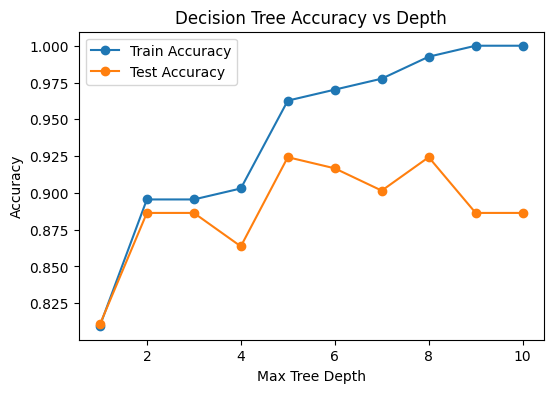

In [15]:
depths = range(1, 11)
train_acc = []
test_acc = []
for d in depths:
    clf = DecisionTreeClassifier(max_depth=d, random_state=42)
    clf.fit(X_train, y_train)
    train_acc.append(clf.score(X_train, y_train))
    test_acc.append(clf.score(X_test, y_test))

plt.figure(figsize=(6,4))
plt.plot(depths, train_acc, label="Train Accuracy", marker='o')
plt.plot(depths, test_acc, label="Test Accuracy", marker='o')
plt.xlabel("Max Tree Depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree Accuracy vs Depth")
plt.legend()
plt.show()

*Training and testing accuracy as a function of decision tree depth. At depth=1 (a decision stump), the tree is very simple and underfits (both train and test accuracy are low). Increasing depth initially improves both train and test accuracy as the model captures more complex patterns. Test accuracy peaks around an intermediate depth (here around 5). Beyond that, training accuracy continues to increase (reaching 1.0 by depth 9 as the tree perfectly memorizes the training data), but test accuracy stops improving and can even decline (here the test accuracy dips by depth 9). This indicates **overfitting** – the deep tree is modeling noise or specifics of the training data that don’t generalize. The optimal depth is one that maximizes validation/test accuracy, balancing bias and variance.*

We observe that:

* For very low depth, the model underfits (high bias, low variance) — it’s too simple to capture the data structure.
* For very high depth, the model overfits (low bias, high variance) — it memorizes the training data intricacies.
* There is an intermediate depth where the model performs best on unseen data.

In practice, we would use techniques like cross-validation to find the optimal tree depth or use **pruning** methods. Scikit-learn also provides `ccp_alpha` (cost-complexity pruning parameter) to prune the tree post-training by penalizing complexity.

### Other Considerations for Decision Trees

* **Handling continuous vs categorical features:** Our implementation and examples treat features as continuous (using thresholds). For categorical features, decision trees can split on each category or grouping of categories. Scikit-learn handles categoricals by one-hot encoding or similar preprocessing since it doesn't natively support non-numeric features.

* **Multi-class classification:** The impurity measures (Gini, entropy) naturally extend to multiple classes (they sum over all class probabilities in the node). The tree-building process is the same – it will try to isolate classes.

* **Regression Trees:** For regression, trees use a different criterion (typically mean squared error or absolute error) to decide splits, and leaves contain a numeric prediction (often the mean of targets in that leaf). The concepts of overfitting and max depth apply similarly.

* **Feature importance:** One nice byproduct of decision trees is that you can derive feature importance metrics (how much each feature split reduces impurity in the tree, averaged over all splits). This can give insight into which features the model found most informative.

* **Stability:** A drawback of trees is that they can be unstable; a small change in data might produce a different series of splits. Ensemble methods like Random Forests (many trees combined) address this, but that’s beyond our current scope.

### Summary: Decision Tree Pros and Cons

**Advantages:**

* **Interpretability:** The model can be visualized and understood as a set of rules. Even without a chart, rules can be listed as shown, which is great for explainability.
* **Flexibility:** Can model non-linear relationships and feature interactions. No need for feature scaling or normalization (splitting is scale-invariant for each feature).
* **Fast inference:** Once the tree is built, predictions are fast (just traverse down the tree).
* **Handles mixed feature types:** Can accommodate both continuous and categorical (with appropriate handling) and can naturally handle missing values (by assigning defaults or splitting instances proportionally, though not implemented above).

**Disadvantages:**

* **Overfitting tendency:** Decision trees are prone to overfitting if not controlled by hyperparameters or pruning. A fully grown tree can memorize training data.
* **Unstable:** Small variations in data can lead to a different tree structure. This is mitigated by ensembling (Random Forests, Boosting).
* **Bias to splits on many-valued features:** A feature with many possible split points (or many categories) can often yield a seemingly good split by chance (this is addressed by techniques like adjusting impurity for number of splits or using ensemble methods).
* **Optimal tree search is hard:** The greedy algorithm doesn't guarantee a globally optimal tree. It’s an NP-hard problem to find the optimal decision tree. Greedy methods work well in practice but can be suboptimal.

Despite these issues, decision trees are a foundational technique and are particularly powerful when used in ensembles.